# Dimensionality Reduction – PCA  
**Use Case:** Maersk Warehouse Sensor Monitoring

This demo shows how PCA helps us reduce dimensionality in high-volume sensor data collected from Maersk warehouses. We'll generate synthetic data to simulate warehouse sensor logs and use PCA to visualize the key patterns.


In [1]:
# --- Setup ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [ ]:
# --- 1. Generate Synthetic Sensor Data (Simulating Maersk Warehouse Logs) ---

# Let's say each row is a timestamped record of 6 warehouse sensors
np.random.seed(42)  # For reproducibility
n_samples = 500
sensor_data = {


}
df = pd.DataFrame(sensor_data)
df.head()

/var/folders/y2/37476f0n7c793jplk1lghrkjr8cwhw/T/ipykernel_40295/3141223884.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'timestamp': pd.date_range(start='2024-01-01', periods=n_samples, freq='H'),


,timestamp,temperature,humidity,vibration,CO2_level,noise_db,light_lux
0,2024-01-01 00:00:00,25.993428,54.630888,0.269968,423.350832,53.248217,345.649040
1,2024-01-01 01:00:00,24.723471,59.547083,0.246232,383.464429,58.554813,377.454773
2,2024-01-01 02:00:00,26.295377,43.007162,0.202982,375.454033,52.075801,273.495329
3,2024-01-01 03:00:00,28.046060,52.814846,0.167653,399.898766,56.920385,251.021061
4,2024-01-01 04:00:00,24.531693,46.746787,0.234911,394.894461,41.063853,213.187958


In [3]:
# --- 2. Data Preprocessing: Standardize Sensor Values ---
# We'll drop the timestamp and scale the sensor features
features = df.columns[1:]  # exclude 'timestamp'
X = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# --- 3. Apply PCA to Reduce Dimensions to 2 Components ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a new DataFrame with principal components
df_pca = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])

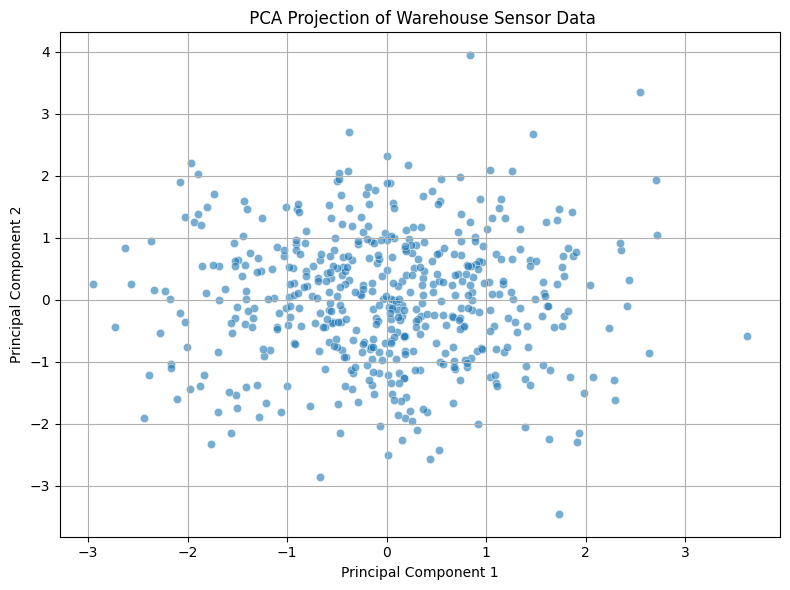

In [8]:
# --- 4. Visualize the Results: PCA Projection Plot ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, alpha=0.6)
plt.title(' PCA Projection of Warehouse Sensor Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

In [6]:
# --- 5. Explained Variance (Optional Evaluation) ---
# Helps understand how much variance each component explains
explained_var = pca.explained_variance_ratio_
print(f"Explained Variance by PC1: {explained_var[0]:.2f}")
print(f"Explained Variance by PC2: {explained_var[1]:.2f}")

Explained Variance by PC1: 0.20
Explained Variance by PC2: 0.18


---  
### 🛠 Optional Enhancements  
- Try 3D PCA and plot in 3D  
- Explore t-SNE or UMAP for non-linear dimensionality reduction  
- Apply clustering on PCA results to group warehouse states